In [1]:
!pip install Pinecone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.6/516.6 kB 6.8 MB/s eta 0:00:00


In [2]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from pinecone import Pinecone
from google.colab import userdata

pc = Pinecone(api_key=userdata.get("PineconeKey"))
index = pc.Index("finance-rag")

all_ids = []
for id_batch in index.list(namespace="academic-papers"):
    all_ids.extend(id_batch)     # each batch is a list of IDs :contentReference[oaicite:3]{index=3}

print(f"Found {len(all_ids)} chunk IDs")

Found 935 chunk IDs


In [3]:
batch_size = 100
all_records = {}   # id → record dict

for i in range(0, len(all_ids), batch_size):
    batch = all_ids[i : i + batch_size]
    resp = index.fetch(
        ids=batch,
        namespace="academic-papers"
    )
    # merge this batch’s vectors into your master dict
    all_records.update(resp.vectors)

print(f"Fetched {len(all_records)} records out of {len(all_ids)} total.")

Fetched 935 records out of 935 total.


In [4]:
ids   = list(all_records.keys())
vecs  = [all_records[_id]['values'] for _id in ids]
chunks = [all_records[_id]['metadata']['text'] for _id in ids]

In [5]:
chunks[0]

'whetherthemarginaldollarofcashflowisworthmoretoshareholders invested inside the corporation or paid out as dividends. Giventheseconsiderations,wehavechosenfirmsizeandtheexistence of a bond rating as indicators of financial strength. The rationale for usingsizeisthatsmallfirmsaremorelikelytobeyoungerandtherefore metries. Since firm size is not a choice variable for the manager in the short run and is unlikely to depend on investment over the short time period covered by our panel, we can regard it as exogenous. Because it is a continuous variable, we classify a firm as “small” if for all four years of the sample it is in the lower third of each year’s distribution of total assets and each year’s distribution of the capital stock. This strainedfirms.Alternatedefinitionsrequiringmembershipinthelower Turning to our other measure of financial health, we classify a firm as unconstrained if it'

In [ ]:
X = np.vstack(vecs)   # shape = (n_chunks, embedding_dim)

# 3) cluster into K topics
K = 10
kmeans = KMeans(n_clusters=K, random_state=42).fit(X)

# 4) find the single chunk per cluster closest to its centroid
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
rep_ids = [ids[i] for i in closest]


print("Representative chunk IDs:", rep_ids)
print("Rep IDS length:", len(rep_ids))

Representative chunk IDs: ['22dab79d-2824-4092-a6f4-6f322fe55e59', '0eb72f00-4fbe-47fb-bc4b-2e346a97807b', '79384bfe-c85e-482e-89fe-f78ce89cf663', '46f2f691-c7ef-4835-a534-b5da191a90c0', '94ffc23e-1f7b-4370-a0aa-a454df2d6242', 'cab4d6c4-b119-428e-a1f7-e9a615132fec', '76bcef74-4fd4-4318-aef5-4d0073460a1d', '059fbc18-5a3e-4391-83e5-3bc8312882f6', '411ca021-6d59-4f14-a3cd-70d2fa6cd8c9', '422d8b83-31f1-4ead-aef1-58f664dacd54']
Rep IDS length: 10


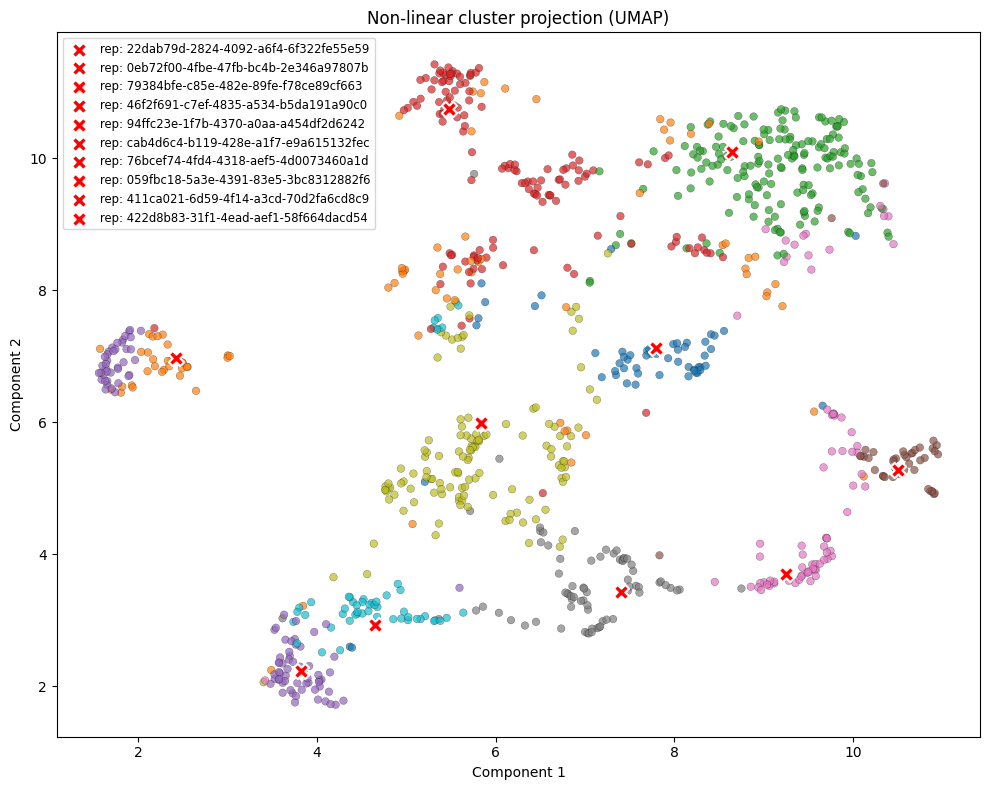

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap                # pip install umap-learn
from sklearn.manifold import TSNE

def visualize_clusters_nonlinear(
    X: np.ndarray,
    ids: list[str],
    rep_ids: list[str],
    kmeans,
    method: str = "umap",
    random_state: int = 42
):
    """
    Project X to 2D using a non-linear reducer (UMAP or t-SNE),
    plot points colored by cluster, and highlight the representative per cluster.

    Parameters
    ----------
    X : array, shape (n_samples, n_features)
        Your chunk embeddings.
    ids : list of str
        Chunk IDs corresponding to rows of X.
    rep_ids : list of str
        One representative ID per cluster.
    kmeans : fitted sklearn.cluster.KMeans
        The clustering you ran on X.
    method : {'umap', 'tsne'}
        Which non-linear reducer to use.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    fig, ax : matplotlib objects
    """

    # 1) Non-linear dimensionality reduction
    if method == "umap":
        reducer = umap.UMAP(n_components=2, random_state=random_state)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=random_state, init="random")
    else:
        raise ValueError("method must be 'umap' or 'tsne'")

    Z = reducer.fit_transform(X)   # shape = (n_samples, 2)

    # 2) Cluster labels and rep indices
    labels = kmeans.labels_
    rep_idx = {rid: ids.index(rid) for rid in rep_ids}

    # 3) Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        Z[:, 0], Z[:, 1],
        c=labels,
        cmap="tab10",
        s=30,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.2
    )
    # highlight reps
    for rid, idx in rep_idx.items():
        ax.scatter(
            Z[idx, 0], Z[idx, 1],
            marker="X", s=120,
            c="red", edgecolor="white", linewidth=1.5,
            label=f"rep: {rid}"
        )

    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(f"Non-linear cluster projection ({method.upper()})")
    # dedupe legend entries
    handles, labels_ = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()
    return fig, ax

fig_umap, ax_umap = visualize_clusters_nonlinear(X, ids, rep_ids, kmeans, method="umap")

In [ ]:
# retrieve chunk texts of reps id
reps = index.fetch(ids=rep_ids, namespace="academic-papers").vectors

In [ ]:
reps_text = [reps[rid].metadata['text'] for rid in rep_ids]

In [ ]:
reps_text

## Lets try BERTopic

In [6]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [7]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

In [ ]:
# # 3A) configure UMAP & HDBSCAN (set random_state for reproducibility)
# umap_model = UMAP(n_neighbors=15, n_components=5,
#                   min_dist=0.0, metric='cosine', random_state=42)
# hdbscan_model = HDBSCAN(min_cluster_size=10,
#                         metric='euclidean',
#                         cluster_selection_method='eom')

# # 3B) build BERTopic with your reducers & custom embeddings
# topic_model = BERTopic(umap_model=umap_model,
#                        hdbscan_model=hdbscan_model,
#                        embedding_model=None,
#                        calculate_probabilities=False)

In [8]:
vecs_np = np.array(vecs)

In [9]:
from bertopic.vectorizers import ClassTfidfTransformer

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
topic_model = BERTopic(ctfidf_model=ctfidf_model)
topics, probs = topic_model.fit_transform(chunks, vecs_np)

In [10]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,68,-1_that_squares_is_by,"[that, squares, is, by, financial, flow, cost,...","[error, so that 2  0, then,  , the estimated..."
1,0,257,0_estimators_ew_estimator_monte,"[estimators, ew, estimator, monte, bias, iv, e...","[. However, our results differ sharply from th..."
2,1,99,1_rents_intangibles_gap_sectors,"[rents, intangibles, gap, sectors, sector, ris...","[Tech, Healthcare, and Manufacturing. In the M..."
3,2,81,2_intangible_physical_capital_total,"[intangible, physical, capital, total, rd, sga...",[our q proxy on the true q. We find that ⌧2 is...
4,3,73,3_proxy_proxies_stands_book,"[proxy, proxies, stands, book, for, quality, t...",[Ross (1981) proxy for q. NBER stands for the ...
5,4,71,4_bond_qbond_prices_leverage,"[bond, qbond, prices, leverage, idiosyncratic,...",[onotattemptin thispapertoexplainthemeaningoft...
6,5,59,5_marginal_fitted_state_tobins,"[marginal, fitted, state, tobins, variables, a...","[addition, since we estimate marginal q indepe..."
7,6,58,6_innovation_learning_volatility_flows,"[innovation, learning, volatility, flows, jump...",[purchase price of capital ⌫ . In our model as...
8,7,49,7_equity_external_collateral_debt,"[equity, external, collateral, debt, credit, b...",[average Q in a setting in which the firm fina...
9,8,40,8_profit_operating_regime_value,"[profit, operating, regime, value, optimal, ma...","[among optimal investment, , and cash flow. As..."


In [11]:
topic_model.get_topic(0)

[('estimators', np.float64(0.34074433737849646)),
 ('ew', np.float64(0.30317511084150445)),
 ('estimator', np.float64(0.2694437114546176)),
 ('monte', np.float64(0.26546071450710745)),
 ('bias', np.float64(0.2586357955347782)),
 ('iv', np.float64(0.2585527417875852)),
 ('estimates', np.float64(0.2514253116869811)),
 ('are', np.float64(0.24860490826480228)),
 ('that', np.float64(0.23999479114585562)),
 ('we', np.float64(0.23781301556102294))]

In [12]:
topic_model.visualize_topics()

Lower left: 2, 3, 5, 6, 8, 9, 11 \\
Upper right: 0, 1, 4, 7, 10 \\

Upper‑right cluster (0, 1, 4, 7, 10) covers things like EW‐estimators, sector gaps, bond prices, collateral, bootstrap biases.

Lower‑left cluster (2, 3, 5, 6, 8, 9, 11) covers intangible/physical capital, proxies for q, Tobin’s marginal q, innovation/volatility, operating regimes, policy, tax functions.

In [14]:
topic_info = topic_model.get_topic_info()

In [15]:
import pandas as pd

with pd.option_context('display.max_colwidth', None):
    # this will print the Representation column in full
    print(topic_info[['Representation']])

                                                                                      Representation
0                                     [that, squares, is, by, financial, flow, cost, cash, firm, to]
1                             [estimators, ew, estimator, monte, bias, iv, estimates, are, that, we]
2                     [rents, intangibles, gap, sectors, sector, rising, capital, user, returns, nt]
3                   [intangible, physical, capital, total, rd, sga, theory, measure, we, investment]
4                     [proxy, proxies, stands, book, for, quality, true, different, lr, measurement]
5      [bond, qbond, prices, leverage, idiosyncratic, bonds, mapping, mispricing, volatility, there]
6   [marginal, fitted, state, tobins, variables, adjustment, function, variation, costs, investment]
7        [innovation, learning, volatility, flows, jumps, research, r2, tobins, figure, innovations]
8            [equity, external, collateral, debt, credit, bank, model, overhang, firm, shar

In [16]:
topic_info['Representative_Docs'][1]

['. However, our results differ sharply from those in ACG. They argue that the EW estimators are biased and inefficient infinitesamples,eventhoughtheyareasymptoticallyconsistentandefficient (Erickson and Whited 2002), and even when all estimator assumptions are satisfied. They conclude that the AB and IV estimators perform better. Therefore, the second goal of this article is to understand the differences putetheoveridentifiedEWestimators,whichrequirenumericalminimization ofanobjectivefunction.Establishedpracticeistochecktheresultingestimates to ensure that they correspond to a global, rather than a local, minimum (e.g., Heckman and Singer 1984). However, most of the poor Monte Carlo performance of the EW estimators in ACG can be traced to a tiny number of extreme estimates, each of which is from a local minimum. This issue affects performance because a Monte Carlo evaluation of an estimator’s bias is itself a statistical estimate',
 'strong assumptions about serial correlation that ar

In [17]:
topic_model.visualize_documents(chunks, embeddings=vecs_np)

In [22]:
topic_info['Representative_Docs'][6]

['addition, since we estimate marginal q independently from adjustment Furthermore, since we only use the variation in market values driven by fundamental state variables in constructing marginal q, we can also minimize tential stock market ine\x00ciencies (Blanchard et al., 1993). Finally and importantly, it is worth noting that the successful empirical identification of marginal q in our framework does not require identification and measurement of all state variables a\x00ecting firm value, but rather only 11Formally Abel and Eberly (1994) show that marginal q is proportional to (average) a subset a\x00ecting its partial derivative with respect to capital. Moreover, when using a large panel of firms, we can easily rely on widely used statistical coe\x00cients to fully account for the impact of any aggregate state variable. We now describe the data used in the empirical analysis and additional issues jection measure of marginal q to estimate capital adjustment costs, investigate Our d

In [23]:
topic_model.get_document_info(chunks)

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,whetherthemarginaldollarofcashflowisworthmoret...,0,0_estimators_ew_estimator_monte,"[estimators, ew, estimator, monte, bias, iv, e...","[. However, our results differ sharply from th...",estimators - ew - estimator - monte - bias - i...,1.000000,False
1,entsimplyfor“pure to decreasing returns). Spec...,1,1_rents_intangibles_gap_sectors,"[rents, intangibles, gap, sectors, sector, ris...","[Tech, Healthcare, and Manufacturing. In the M...",rents - intangibles - gap - sectors - sector -...,0.784365,False
2,"key state variables. Moreover, we show that el...",9,9_state_policy_variables_adjusted,"[state, policy, variables, adjusted, aic, 7936...",[an artificial panel and use the simulated dat...,state - policy - variables - adjusted - aic - ...,0.929496,False
3,"Koijen, Boris Nikolov (discussant), Stavros Pa...",5,5_marginal_fitted_state_tobins,"[marginal, fitted, state, tobins, variables, a...","[addition, since we estimate marginal q indepe...",marginal - fitted - state - tobins - variables...,0.894266,False
4,"criticalvaluefrom 1,000bootstraptrials.tαrefer...",0,0_estimators_ew_estimator_monte,"[estimators, ew, estimator, monte, bias, iv, e...","[. However, our results differ sharply from th...",estimators - ew - estimator - monte - bias - i...,1.000000,False
...,...,...,...,...,...,...,...,...
930,and Tobin’s q allows us to assess the relative...,6,6_innovation_learning_volatility_flows,"[innovation, learning, volatility, flows, jump...",[purchase price of capital ⌫ . In our model as...,innovation - learning - volatility - flows - j...,0.850942,False
931,levant.ItisimportantthatweexaminehowtheEWandth...,0,0_estimators_ew_estimator_monte,"[estimators, ew, estimator, monte, bias, iv, e...","[. However, our results differ sharply from th...",estimators - ew - estimator - monte - bias - i...,1.000000,False
932,expressing the model in terms of deviations fr...,3,3_proxy_proxies_stands_book,"[proxy, proxies, stands, book, for, quality, t...",[Ross (1981) proxy for q. NBER stands for the ...,proxy - proxies - stands - book - for - qualit...,0.512405,False
933,test the theory’s predictions in our full samp...,2,2_intangible_physical_capital_total,"[intangible, physical, capital, total, rd, sga...",[our q proxy on the true q. We find that ⌧2 is...,intangible - physical - capital - total - rd -...,0.656296,False


In [24]:
document_info = topic_model.get_document_info(chunks)

In [26]:
# get all chunks with label x
label = 5
len(document_info[document_info['Topic'] == label])

59

In [27]:
# randomly print out 10 of those
import random
random.sample(list(document_info[document_info['Topic'] == label]['Document']), 10)

['investment and capital. Specifically, we use the following polynomial specification for the investment price. For example, the price of capital may systematically vary across firms due to tax considerations such as the value of investment tax credits and depreciation allowances. While this function is not restricted to be globally convex, we verify that the estimates imply convexity. ment policy in (7) and can be estimated as native measures of Q. Empirically, we use various measures of Q discussed in the paper as the dependent variable in (15). obtained with standard Tobin’s Q, Fitted Q, and the projection measure of specification. Columns (7) of Table 5 shows that the positive and significant ment cost parameter of only about 2.02. This is much smaller than the value implied by the use of (average) Tobin’s Q in column (1), 11.94, and Fitted Q This table reports estimates from the following regression: Robust standard errors are clustered by firm and reported in parent',
 'marginal 

Next steps:
1. push labels for chunks into Pinecone metadata, so we can filter on labels
2. Or directly select repersentative docs and use those. they seem to be in much better quality